From https://eloy.readthedocs.io/en/latest/photometry/

In [ ]:
from astropy.io import fits
from dateutil import parser
from glob import glob

images = glob("/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/*.fits.fz")
#images = glob("data/*.fits.fz")

# get observation time from FITS header (SCI extension)
def observation_time(file):

    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    return parser.parse(date_str)


# order by observation time
images = sorted(images, key=lambda file: observation_time(file))


['/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d70800286_20260615_1a367_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d73132114_20260615_1a311_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d73996414_20260615_1a294_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d73931845_20260615_1a299_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d71356425_20260615_1a353_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d72176735_20260615_1a332_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/NxAst-3c371_ip_2461207d73191088_20260615_1a310_20_baron.fits.fz', '/home/adamarthurryan/Desktop/baron obs/3c371/3

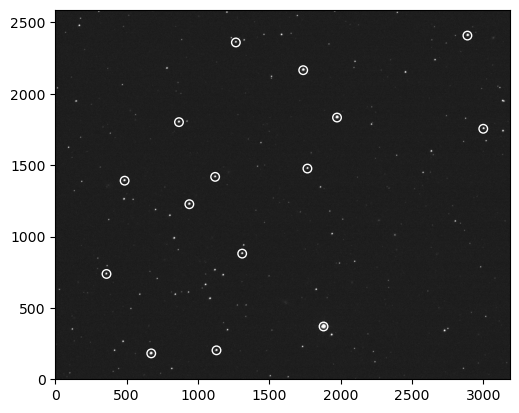

In [7]:


import matplotlib.pyplot as plt
import numpy as np
from eloy import viz
from eloy import detection

# pick a reference image from the stack
reference = images[0]

# detect stars in the reference image and return their coordinates
def detect_stars_coords(data):
    regions = detection.stars_detection(data)
    # stars coords and cutouts
    region_coords = np.array(
        [(r.centroid_weighted[1], r.centroid_weighted[0]) for r in regions]
    )

    return region_coords


# detect stars in the reference image and return their coordinates
reference_coords = detect_stars_coords(fits.getdata(reference))[0:15]

# visualize the reference image and detected stars
plt.imshow(viz.z_scale(fits.getdata(reference)), cmap="Greys_r", origin="lower")
viz.plot_marks(*reference_coords.T, color="w", ms=30)



In [8]:
from skimage.transform import warp
from eloy import alignment
from tqdm.auto import tqdm

ref_reference = alignment.twirl_reference(reference_coords)

# align the data with the detected stars in the reference image
def warp_data(data):
    coords = detect_stars_coords(data)[0:15]
    X = alignment.rotation_matrix(coords, reference_coords, ref_reference)
    warpped_data = warp(data.astype(float), X)
    return warpped_data


# align and stack the images
stack_image = np.zeros_like(fits.getdata(reference))

for image in tqdm(images):
    aligned_image = warp_data(fits.getdata(image))
    stack_image += aligned_image

# this is maybe screwing up the wcs?
hdu = fits.PrimaryHDU(data=stack_image, header=fits.getheader(reference, extname='sci'))
filename = "output/stack_image.fits"
hdu.writeto(filename, overwrite=True)


  0%|          | 0/97 [00:00<?, ?it/s]

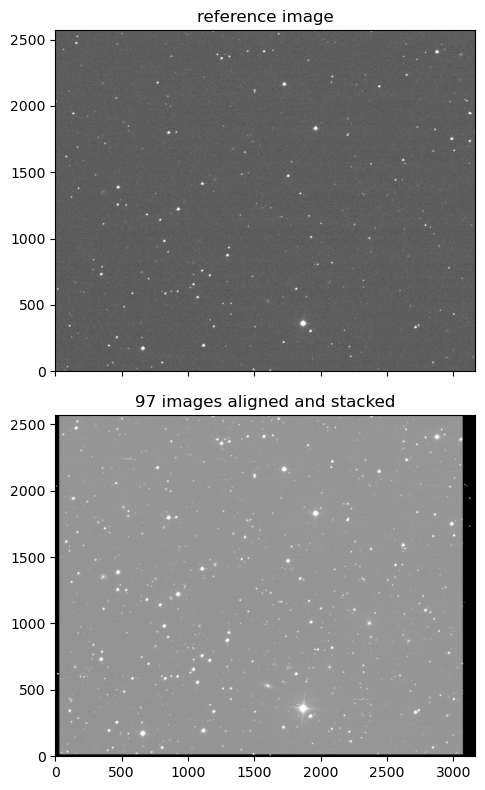

In [9]:
#display stacked image and reference image
ref_data = fits.getdata(reference)

fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True, sharey=True)
axes[0].imshow(viz.z_scale(ref_data[10:-10, 10:-10]), cmap="Greys_r", origin="lower")
axes[0].set_title("reference image")
axes[1].imshow(viz.z_scale(stack_image[10:-10, 10:-10]), cmap="Greys_r", origin="lower")
axes[1].set_title(f"{len(images)} images aligned and stacked")
plt.tight_layout()
